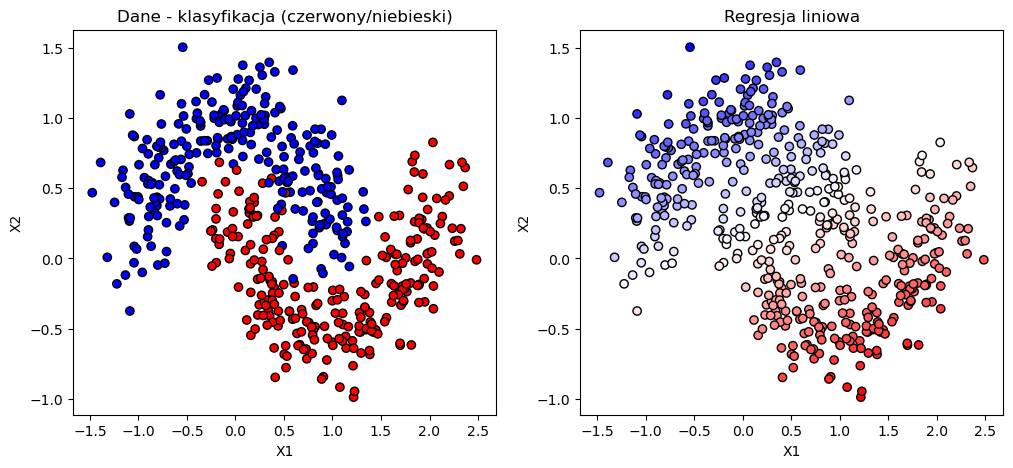

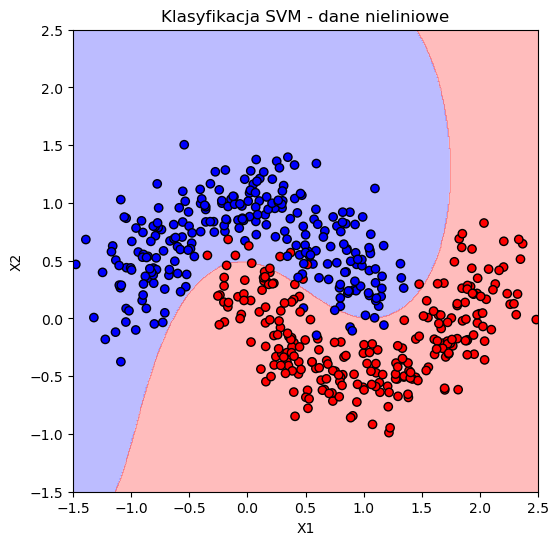

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
import seaborn as sns

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title("Dane - klasyfikacja (czerwony/niebieski)")
plt.xlabel("X1")
plt.ylabel("X2")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='bwr', edgecolor='k')
plt.title("Regresja liniowa")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

# Klasyfikacja SVM z jądrem RBF
clf = SVC(kernel='rbf', gamma='auto') #C-Support Vector Classification.
clf.fit(X, y)

# Rysowanie granicy decyzyjnej SVM
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 500), np.linspace(-1.5, 2.5, 500))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title("Klasyfikacja SVM - dane nieliniowe")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


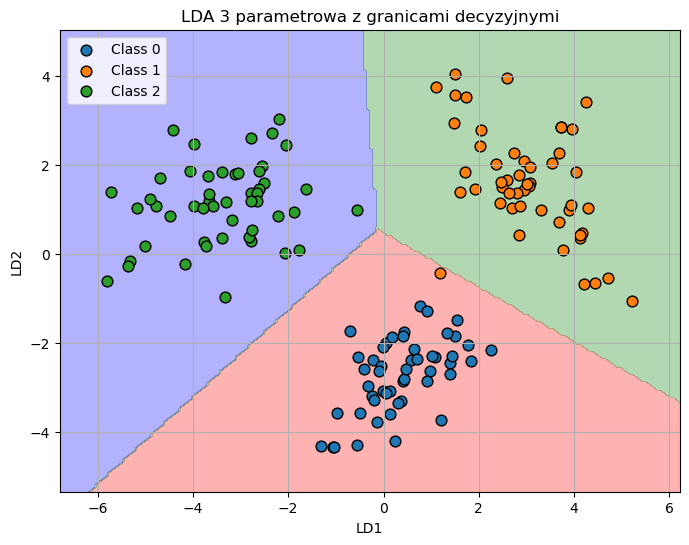

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# -------------------------------
# 1. Generowanie danych 3D
# -------------------------------
np.random.seed(42)
n_samples = 50

# Klasa 1
mean1 = [0, 0, 0]
cov1 = [[1, 0.8, 0.5], [0.8, 1, 0.3], [0.5, 0.3, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, n_samples)

# Klasa 2
mean2 = [3, 3, 3]
cov2 = [[1, -0.5, 0], [-0.5, 1, 0.2], [0, 0.2, 1]]
X2 = np.random.multivariate_normal(mean2, cov2, n_samples)

# Klasa 3
mean3 = [-3, 3, 0]
cov3 = [[1, 0.2, 0.5], [0.2, 1, -0.3], [0.5, -0.3, 1]]
X3 = np.random.multivariate_normal(mean3, cov3, n_samples)

# Dane i etykiety
X = np.vstack((X1, X2, X3))
y = np.array([0]*n_samples + [1]*n_samples + [2]*n_samples)

# -------------------------------
# 2. Dopasowanie LDA
# -------------------------------
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)  # Projekcja 3D -> 2D

# -------------------------------
# 3. Przygotowanie siatki do granic
# -------------------------------
x_min, x_max = X_lda[:,0].min() - 1, X_lda[:,0].max() + 1
y_min, y_max = X_lda[:,1].min() - 1, X_lda[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Tworzymy nowy LDA tylko w przestrzeni 2D dla predykcji granic
lda2D = LinearDiscriminantAnalysis()
lda2D.fit(X_lda, y)

# Predykcja dla siatki
Z = lda2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -------------------------------
# 4. Wykres 2D z granicami decyzyjnymi
# -------------------------------
plt.figure(figsize=(8,6))
# Kolorowe obszary granic
plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5,0.5,1.5,2.5], colors=['r','g','b'])

# Punkty danych
for label, color in zip([0,1,2], ['r','g','b']):
    plt.scatter(X_lda[y==label,0], X_lda[y==label,1], label=f'Class {label}', edgecolor='k', s=60)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA 3 parametrowa z granicami decyzyjnymi')
plt.legend()
plt.grid(True)
plt.show()
